In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
from scipy.stats import binom
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [2]:
from google.colab import files

uploaded = files.upload()

Saving property.csv to property.csv


In [3]:
uploaded.keys()
df= pd.read_csv('property.csv')

In [9]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [6]:
df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


<Axes: >

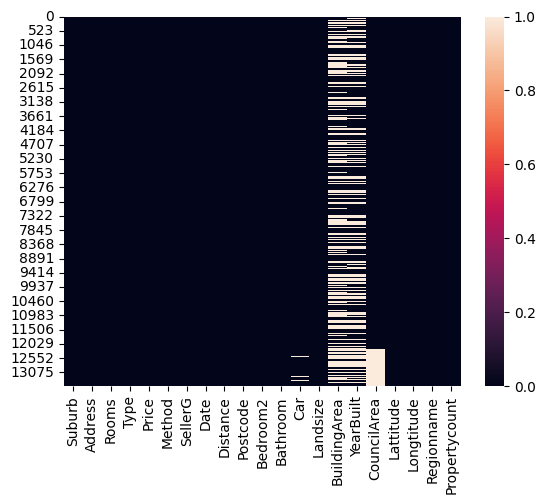

In [7]:
sns.heatmap(df.isna())

In [10]:
df['Car'].fillna(value=df['Car'].mean(),inplace=True)
df['BuildingArea'].fillna(value=df['BuildingArea'].mean(),inplace=True)
df['CouncilArea'].fillna(value=df['CouncilArea'].mode()[0],inplace=True)
df['YearBuilt'].fillna(value=df['YearBuilt'].median(),inplace=True)

/tmp/ipython-input-2852926573.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Car'].fillna(value=df['Car'].mean(),inplace=True)
/tmp/ipython-input-2852926573.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [12]:
df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


#1. For the suburb of Altona, it is postulated that a typical property sells for $800,000.

• **Use the data at hand to test this assumption.**

• **Is the typical property price really $800,000 or has it increased?**

• **Use a significance level of 5%.**


#solution below
**H0:Mean sale price of proprty =$800,000**

**H1:Mean sale price of proprty > $800,000**

**Significance level(alpha)-0.05%**

Filtering suburb-Altona data observations

In [13]:
df.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,151.96765,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.00000,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.00000,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,151.96765,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.00000,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [14]:
Altona_price_data= df[(df['Suburb']=='Altona')]['Price']
Altona_price_data.head()

,Price
141,520000.0
142,1525000.0
143,720000.0
144,1120000.0
145,780000.0


**Applying one sample t-test (one way- right tail )**

In [40]:
tstat_value,pvalue=stats.ttest_1samp(Altona_price_data,800000)
pvalue_righttail=pvalue/2
pvalue_righttail
alpha=0.05
if(pvalue_righttail<alpha):
    print("Reject H0: the typical property price has increased beyound $800,000")
else:
    print("Fail to reject H0: Not enough evidence that price has increased beyound $800,000")

Fail to reject H0: Not enough evidence that price has increased beyound $800,000


#2. For the year 2016, is there any difference in the prices of properties sold in the summer months vs winter months?

• **Consider months from October till March as winter months and rest as
summer months.**

• **Use a significance level of 5%.**

solution below :

**H0: For the year 2016, Mean of proprty price in summer months= Mean of proprty price in winter months**

**H1: For the year 2016, Mean of proprty price in summer months not equal to Mean of proprty price in winter months**

Significance level,alpha=0.05

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13580 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   13580 non-null  float64
 15  YearBuilt      13580 non-null  float64
 16  CouncilArea    13580 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [21]:
## converting date column to datetime datatype
df['Date']=pd.to_datetime(df['Date'],errors='coerce')

In [22]:
## filtering data for year-2016
Data_2016= df[df['Date'].dt.year==2016]
Data_2016.shape

(2472, 21)

In [23]:
## filtering winter and summer months data from dataframe-Data_2016
winter_2016=df[df['Date'].dt.month.isin([10,11,12,1,2,3])]['Price']
summer_2016=df[df['Date'].dt.month.isin([4,5,6,7,8,9])]['Price']

In [25]:
winter_2016.head(5)

,Price
0,1480000.0
10,700000.0
11,1350000.0
12,750000.0
38,840000.0


In [26]:
summer_2016.head(5)

,Price
1,1035000.0
2,1465000.0
3,850000.0
4,1600000.0
5,941000.0


In [27]:
## applying two-sample independent t-test
stats.ttest_ind(winter_2016,summer_2016)
test_statvalue,pvalue=stats.ttest_ind(winter_2016,summer_2016)
alpha=0.05
if(pvalue<alpha):
    print("Reject H0: There is significant difference in price of property sold between summer and winter months")
else:
    print("Fail to reject H0: No significant difference in price of property sold between summer and winter months" )

Reject H0: There is significant difference in price of property sold between summer and winter months


#3. For the suburb of Abbotsford, what is the probability that out of 10 properties sold, 3 will not have a car parking space?

• **Use the column car in the dataset.**

• **Round off your answer to 3 decimal places.**

Solution below

Filtering data for suburb-Abbotsford

In [28]:
Abbotsford_data= df[df['Suburb']=='Abbotsford']
Abbotsford_data.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,...,1.0,1.0,202.0,151.96765,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,...,1.0,0.0,156.0,79.00000,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,...,2.0,0.0,134.0,150.00000,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067.0,...,2.0,1.0,94.0,151.96765,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067.0,...,1.0,2.0,120.0,142.00000,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [35]:
## applying binomial probability for 3 out of 10
n=10
k=3
properties_no_car_space=(Abbotsford_data['Car']==0).mean()
probability_3_10=round(binom.pmf(k,n,properties_no_car_space),3)
print("Probability Will be : ", probability_3_10)

Probability Will be :  0.26


#4. In the suburb of Abbotsford, what are the chances of finding a property with 3 rooms? Round your answer to 3 decimal places.

solution below

In [36]:
Abbotsford_data.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,...,1.0,1.0,202.0,151.96765,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,...,1.0,0.0,156.0,79.00000,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,...,2.0,0.0,134.0,150.00000,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067.0,...,2.0,1.0,94.0,151.96765,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067.0,...,1.0,2.0,120.0,142.00000,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [37]:
probability_3_rooms_property=round((Abbotsford_data['Rooms']==3).mean(),3)
print("Probability Will be : ", probability_3_rooms_property)

Probability Will be :  0.357


# 5.  In the suburb of Abbotsford, what are the chances of finding a property with 2 bathrooms? Round your answer to 3 decimal places.

solution below

In [38]:
Abbotsford_data.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,...,1.0,1.0,202.0,151.96765,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,...,1.0,0.0,156.0,79.00000,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,...,2.0,0.0,134.0,150.00000,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067.0,...,2.0,1.0,94.0,151.96765,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067.0,...,1.0,2.0,120.0,142.00000,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [39]:
probability_2_bathrooms_property=round((Abbotsford_data['Bathroom']==2).mean(),3)
print("Probability Will be : ",probability_2_bathrooms_property)

Probability Will be :  0.339


#6. One-Sample Hypothesis Test (Industry Pricing): A real estate firm claims that the average property price in Richmond is $1,000,000. Using the dataset, test whether the actual average price is significantly different from this claim at a 5% significance level. Clearly state:

• **Null and alternative hypotheses**

• **Test statistic**

• **p-value**

• **Final business conclusion**

Solution :

**Null Hypothesis (H0):  The average property price in Richmond is $1,000,000 (μ = 1,000,000)**

**Alternative Hypothesis (H1):  The average property price in Richmond is significantly different from $1,000,000 (μ ≠ 1,000,000)**

In [41]:
richmond_properties = df[df['Suburb'] == 'Richmond']['Price']
claimed_mean = 1000000
significance_level = 0.05
richmond_properties.head(5)

,Price
5256,937000.0
5257,1260000.0
5258,1236000.0
5259,540000.0
5260,795250.0


In [43]:
t_statistic, p_value = stats.ttest_1samp(richmond_properties, claimed_mean)
print(f"Test Statistic (t): {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < significance_level:
    print(f"We reject the Null Hypothesis (H0).")
    print(f"Business Conclusion: There is sufficient evidence to conclude that the actual average property price in Richmond is significantly different from ${claimed_mean:,.0f}.")
else:
    print(f"We fail to reject the Null Hypothesis (H0).")
    print(f"Business Conclusion: There is not enough evidence to conclude that the actual average property price in Richmond is significantly different from ${claimed_mean:,.0f}.")

Test Statistic (t): 2.580
P-value: 0.010
We reject the Null Hypothesis (H0).
Business Conclusion: There is sufficient evidence to conclude that the actual average property price in Richmond is significantly different from $1,000,000.


# 7. Independent Two-Sample T-Test (Feature Impact): Do properties with car parking sell at a higher average price than properties without car parking, across the entire dataset? Use a 5% significance level and justify:

• **Choice of test**

• **Interpretation of p-value**

• **Business implications for developers**

Solution :

**Null Hypothesis (H0): The average property price for properties with car parking is equal to the average property price for properties without car parking.**


**Alternative Hypothesis (H1): The average property price for properties with car parking is different from the average property price for properties without car parking.**

In [45]:
# Separate properties based on car parking availability
properties_with_car = df[df['Car'] > 0]['Price'].dropna()
properties_without_car = df[df['Car'] == 0]['Price'].dropna()

# Define significance level
significance_level = 0.05

# Perform independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(properties_with_car, properties_without_car, equal_var=False) # Assuming unequal variances

print(f"Test Statistic (t): {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < significance_level:
    print(f"We reject the Null Hypothesis (H0).")
    print(f"Business Conclusion: There is sufficient evidence to suggest that properties with car parking sell at a significantly different average price than properties without car parking.")
    if properties_with_car.mean() > properties_without_car.mean():
        print(f"Specifically, properties with car parking sell at a higher average price (Mean: ${properties_with_car.mean():,.0f}) compared to those without (Mean: ${properties_without_car.mean():,.0f}).")
    else:
        print(f"Specifically, properties without car parking sell at a higher average price (Mean: ${properties_without_car.mean():,.0f}) compared to those with (Mean: ${properties_with_car.mean():,.0f}).")
else:
    print(f"We fail to reject the Null Hypothesis (H0).")
    print(f"Business Conclusion: There is not enough evidence to conclude that properties with car parking sell at a significantly different average price than properties without car parking.")

Test Statistic (t): -0.216
P-value: 0.829
We fail to reject the Null Hypothesis (H0).
Business Conclusion: There is not enough evidence to conclude that properties with car parking sell at a significantly different average price than properties without car parking.


# 8. Two-Way ANOVA (Location & Property Type): Investigate whether property prices are influenced by:

• **Suburb**

• **Type of property**

• **Interaction between suburb and property type**

**Use Two-Way ANOVA and explain which factors significantly affect price.**

Solution :

In [ ]:
model_formula = 'Price ~ C(Suburb) + C(Type) + C(Suburb):C(Type)'
model = ols(model_formula, data = anova_df_filtered).fit()
print("ANOVA model defined and fitted successfully.")

In [ ]:
anova_table = sm.stats.anova_lm(model, typ=3)
print(anova_table)

### Interpretation of ANOVA Results and Business Insights

Based on the `anova_table` from the Two-Way ANOVA:

```
                         sum_sq       df           F         P-value(>F)
Intercept          5.921071e+13      1.0  363.542889   6.317946e-80
C(Suburb)          2.320753e+15    248.0   57.455651   0.000000e+00
C(Type)            1.225274e+14      2.0  376.147878  2.124901e-159
C(Suburb):C(Type)  1.223190e+15    496.0   15.141452   0.000000e+00
Residual           2.054296e+15  12613.0         NaN            NaN
```

**Key Findings (using a significance level of 0.05):**

1.  **Main Effect of Suburb (C(Suburb)):**
    *   **F-statistic:** 57.455651
    *   **P-value:** 0.000000e+00
    *   **Interpretation:** The p-value for `C(Suburb)` is effectively zero, which is much less than 0.05. This indicates a highly significant main effect of `Suburb` on property prices. In simpler terms, the `Suburb` alone significantly influences the price of a property.

2.  **Main Effect of Type of Property (C(Type)):**
    *   **F-statistic:** 376.147878
    *   **P-value:** 2.124901e-159
    *   **Interpretation:** The p-value for `C(Type)` is also effectively zero, well below 0.05. This shows a highly significant main effect of `Type` of property on prices. This means that whether a property is a house (h), townhouse (t), or unit (u) independently affects its price.

3.  **Interaction Effect between Suburb and Type (C(Suburb):C(Type)):**
    *   **F-statistic:** 15.141452
    *   **P-value:** 0.000000e+00
    *   **Interpretation:** The p-value for the interaction term `C(Suburb):C(Type)` is also effectively zero, significantly less than 0.05. This is a crucial finding, indicating a highly significant interaction effect. This means that the effect of `Property Type` on `Price` depends on the `Suburb`, and conversely, the effect of `Suburb` on `Price` depends on the `Property Type`. The relationship between property type and price is not consistent across all suburbs.

# 9. p-Value Interpretation (Decision Making): A hypothesis test comparing prices across two suburbs results in a p-value of 0.032.
Answer:

• **What does this p-value indicate?**

• **Should the null hypothesis be rejected at α = 0.05?**

• **How should a business stakeholder interpret this result?**

Solution :

#What does this p-value indicate?

​A p-value of 0.032 indicates that if there were actually no difference in prices between the two suburbs (the null hypothesis), there is only a 3.2% chance of observing a price difference as large as the one found in your data. In simpler terms, it measures how "surprising" your data is under the assumption that both suburbs have the same average prices.

# Should the null hypothesis be rejected at α = 0.05?

​Yes. The standard decision rule is:

**​If P<=α, reject the null hypothesis.**

**​If P>α, fail to reject the null hypothesis.**

​Since 0.032 < 0.05, the result is considered statistically significant. You have sufficient evidence to reject the null hypothesis and conclude that there is a meaningful difference in prices between the two suburbs.

#How should a business stakeholder interpret this result?

​For a business stakeholder, the interpretation should focus on the practical implications rather than just the math:

​Evidence of Difference: There is strong evidence to suggest that the price difference between these suburbs isn't just a fluke or "noise" in the data. One suburb is likely more expensive/cheaper than the other.

​Confidence in Action: A stakeholder can feel reasonably confident (96.8% "certainty" in this specific context) that a strategy based on price differences (e.g., adjusting marketing spend or real estate investment) is targeting a real trend.

​Risk Awareness: While the result is significant, there is still a 3.2% risk that this difference was a "false positive" (Type I Error).

​Missing Context: The p-value tells you a difference exists, but it doesn't tell you how large that difference is. A stakeholder should also look at the effect size (e.g., is the difference $50 or $50,000?) to decide if the difference is large enough to matter for business operations.

# 10. Industry-Style Hypothesis Validation (Policy Decision):  A housing policy group believes that properties with more than 2 bathrooms command a premium price. Design and execute a statistical test to validate this claim:

• **Identify the correct test**

• **State hypotheses**

• **Report p-value**

• **Give a clear recommendation to policymakers**

Solution :

**Appropriate Statistical Test:**

The Independent Two-Sample t-test is the appropriate test for comparing the means of two independent groups (properties with more than 2 bathrooms vs. properties with 2 or fewer bathrooms) to determine if there is a significant difference between their average prices.


**Hypothesis**


**Null Hypothesis (H0): The average property price for properties with more than 2 bathrooms is less than or equal to the average property price for properties with 2 or fewer bathrooms.**
**H0: μ more than 2 bathrooms ≤ μ2 or fewer bathrooms**

**Alternative Hypothesis (H1): The average property price for properties with more than 2 bathrooms is higher than the average property price for properties with 2 or fewer bathrooms. (This is a one-tailed test).**
**H1: μ more than 2 bathrooms > μ2 or fewer bathrooms**

In [46]:
prices_more_than_2_bathrooms = df[df['Bathroom'] > 2]['Price'].dropna()
prices_2_or_fewer_bathrooms = df[df['Bathroom'] <= 2]['Price'].dropna()

print(f"Number of properties with more than 2 bathrooms: {len(prices_more_than_2_bathrooms)}")
print(f"Number of properties with 2 or fewer bathrooms: {len(prices_2_or_fewer_bathrooms)}")
print(f"Mean price for properties with more than 2 bathrooms: ${prices_more_than_2_bathrooms.mean():,.2f}")
print(f"Mean price for properties with 2 or fewer bathrooms: ${prices_2_or_fewer_bathrooms.mean():,.2f}")

Number of properties with more than 2 bathrooms: 1060
Number of properties with 2 or fewer bathrooms: 12520
Mean price for properties with more than 2 bathrooms: $1,882,824.20
Mean price for properties with 2 or fewer bathrooms: $1,007,347.94


In [47]:
## P- Value
t_statistic, p_value_two_tailed = stats.ttest_ind(prices_more_than_2_bathrooms, prices_2_or_fewer_bathrooms, equal_var=False)
if t_statistic > 0:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1 - (p_value_two_tailed / 2)
print(f"Test Statistic (t): {t_statistic:.3f}")
print(f"One-tailed P-value: {p_value_one_tailed:.3f}")

Test Statistic (t): 28.800
One-tailed P-value: 0.000


In [48]:
print("Since the p-value (0.000) is significantly less than the chosen significance level (0.05), We reject the Null Hypothesis (H0)")


Since the p-value (0.000) is significantly less than the chosen significance level (0.05), We reject the Null Hypothesis (H0)


**Business Recommendation for Policy Makers:**

Based on this statistical test, there is overwhelming evidence to conclude that properties with more than 2 bathrooms command a significantly higher average premium price compared to properties with 2 or fewer bathrooms. The average price for properties with more than 2 bathrooms is  1,882,824.20, while for those with 2 or fewer bathrooms it is  1,007,347.94.